In [1]:
import qiskit 
print(qiskit.__version__)

2.3.1


## Max Cut

In [8]:
# basic imports

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# quantum imports
from qiskit_optimization.applications import Maxcut
from qiskit.circuit import Parameter,QuantumCircuit
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import efficient_su2
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_optimization.algorithms import MinimumEigenOptimizer

# SciPy minimizer routine
from scipy.optimize import minimize
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2
from qiskit_aer import AerSimulator
backend = AerSimulator(method='matrix_product_state')


estimator = BackendEstimatorV2(backend=backend)
sampler = BackendSamplerV2(backend=backend)

### Generate a Random Graph

Problem name: Max-cut

Maximize
  -2*x_0*x_1 - 2*x_0*x_3 - 2*x_0*x_4 - 2*x_1*x_2 - 2*x_1*x_5 - 2*x_2*x_3
  - 2*x_2*x_4 - 2*x_3*x_5 - 2*x_4*x_5 + 3*x_0 + 3*x_1 + 3*x_2 + 3*x_3 + 3*x_4
  + 3*x_5

Subject to
  No constraints

  Binary variables (6)
    x_0 x_1 x_2 x_3 x_4 x_5



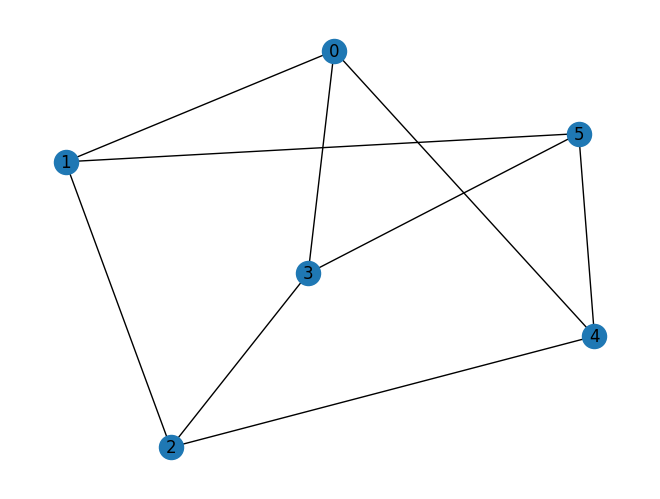

In [3]:
seed = 1
num_nodes = 6
graph = nx.random_regular_graph(d=3, n=num_nodes, seed=seed)
nx.draw(graph, with_labels=True, pos=nx.spring_layout(graph, seed=seed))
# Assign random weights to the edges

maxcut = Maxcut(graph)
problem = maxcut.to_quadratic_program()
print(problem.prettyprint())

### Exact Solution

In [4]:
# solving Quadratic Program using exact classical eigensolver
exact = MinimumEigenOptimizer(NumPyMinimumEigensolver())
result = exact.solve(problem)
print(result.prettyprint())

objective function value: 9.0
variable values: x_0=0.0, x_1=1.0, x_2=0.0, x_3=1.0, x_4=1.0, x_5=0.0
status: SUCCESS


In [5]:
# problem to qubo
converter = QuadraticProgramToQubo()
qubo = converter.convert(problem)
#print(qubo.export_as_lp_string())


In [6]:
qubitOp, offset = qubo.to_ising()
print("Offset:", offset)
print("Ising Hamiltonian:")
print(str(qubitOp))

Offset: -4.5
Ising Hamiltonian:
SparsePauliOp(['IIIIZZ', 'IIZIIZ', 'IZIIIZ', 'IIIZZI', 'ZIIIZI', 'IIZZII', 'IZIZII', 'ZIZIII', 'ZZIIII'],
              coeffs=[0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j,
 0.5+0.j])


### VQE

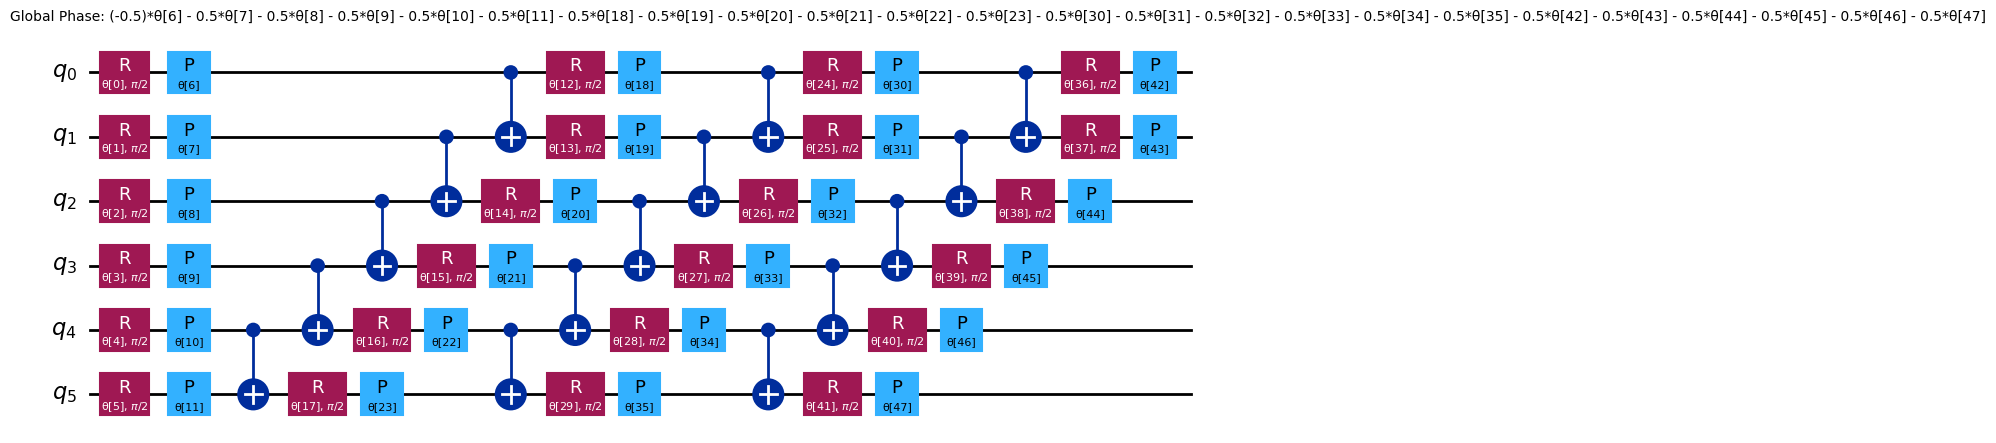

In [9]:
ansatz = efficient_su2(qubitOp.num_qubits)
ansatz.decompose().draw("mpl", style="iqp")

In [10]:
num_params = ansatz.num_parameters
num_params

48

### Execute

In [11]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy

In [12]:
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

In [13]:
x0 = 2 * np.pi * np.random.random(num_params)
x0

array([2.40317215e+00, 4.96825586e+00, 1.89667029e+00, 2.39570045e+00,
       2.44103968e+00, 5.15234033e+00, 5.03200621e+00, 1.12290637e+00,
       2.91152638e+00, 4.36132774e+00, 4.48092172e-01, 3.39215252e-03,
       2.09631125e+00, 6.19505663e+00, 1.98335351e+00, 5.35429110e+00,
       5.42017624e-01, 1.55864700e+00, 4.59552306e-01, 5.36921445e-01,
       1.43485235e+00, 5.63675118e+00, 7.04858984e-01, 1.44189355e+00,
       1.52239445e+00, 5.51220425e+00, 2.70924470e+00, 2.75834651e+00,
       5.17315192e+00, 3.06811688e+00, 1.46357597e-01, 3.21091191e+00,
       3.74877823e+00, 1.95490508e+00, 3.85973566e+00, 3.92577557e+00,
       3.24426906e+00, 5.02485097e+00, 5.91490390e+00, 3.65313524e-01,
       2.18002727e+00, 2.22751582e+00, 1.13339783e+00, 4.16340704e+00,
       1.71450418e-01, 2.82696169e+00, 8.12299266e-01, 3.87625441e+00])

In [14]:
ansatz = ansatz.decompose()

res = minimize(
        cost_func,
        x0,
        args=(ansatz, qubitOp, estimator),
        method="cobyla",
    )

Iters. done: 1 [Current cost: -0.01611328125]
Iters. done: 2 [Current cost: -0.107421875]
Iters. done: 3 [Current cost: -0.0185546875]
Iters. done: 4 [Current cost: -0.166015625]
Iters. done: 5 [Current cost: -0.0947265625]
Iters. done: 6 [Current cost: 0.02197265625]
Iters. done: 7 [Current cost: -0.18359375]
Iters. done: 8 [Current cost: -0.15771484375]
Iters. done: 9 [Current cost: 0.029052734375]
Iters. done: 10 [Current cost: -0.17626953125]
Iters. done: 11 [Current cost: -0.318359375]
Iters. done: 12 [Current cost: -0.131591796875]
Iters. done: 13 [Current cost: -0.258056640625]
Iters. done: 14 [Current cost: -0.391357421875]
Iters. done: 15 [Current cost: -0.315673828125]
Iters. done: 16 [Current cost: -0.14697265625]
Iters. done: 17 [Current cost: -0.18408203125]
Iters. done: 18 [Current cost: -0.42041015625]
Iters. done: 19 [Current cost: -0.2919921875]
Iters. done: 20 [Current cost: -0.459716796875]
Iters. done: 21 [Current cost: -0.39404296875]
Iters. done: 22 [Current cost:

In [15]:
res

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -4.2109375
       x: [ 3.162e+00  6.356e+00 ...  1.587e+00  4.124e+00]
    nfev: 573
   maxcv: 0.0

### Post Processing

In [16]:
all(cost_history_dict["prev_vector"] == res.x)

True

In [17]:
cost_history_dict["iters"] == res.nfev

True

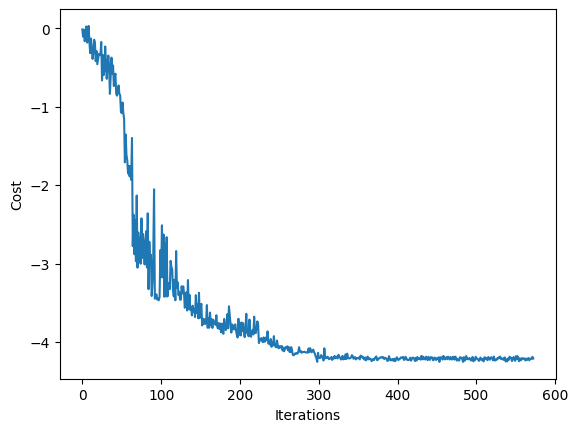

In [18]:
fig, ax = plt.subplots()
ax.plot(range(cost_history_dict["iters"]), cost_history_dict["cost_history"])
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost")
plt.draw()

### Run the Optimizer Params

In [ ]:
ansatz = ansatz.assign_parameters(res.x)

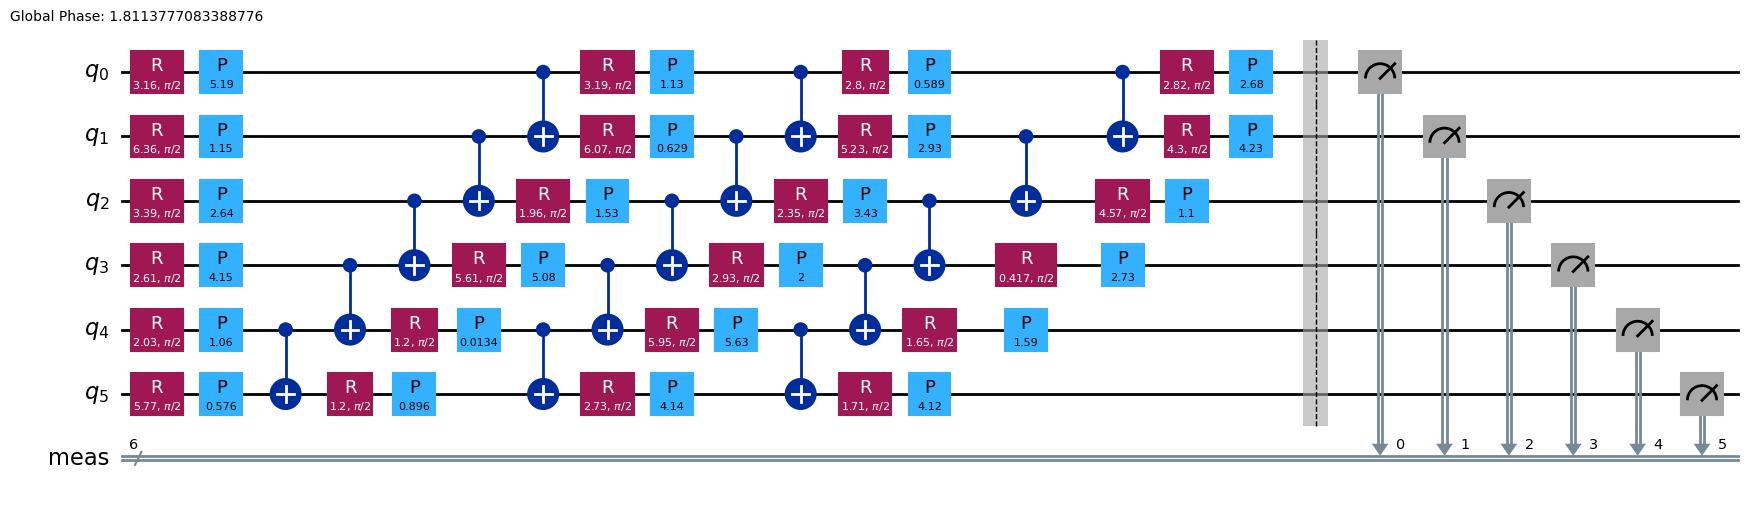

In [20]:
ansatz.measure_all()
ansatz.draw("mpl", style="iqp")

In [21]:
pub = (ansatz,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}

In [22]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, num_nodes)
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [0, 1, 0, 1, 1, 0]


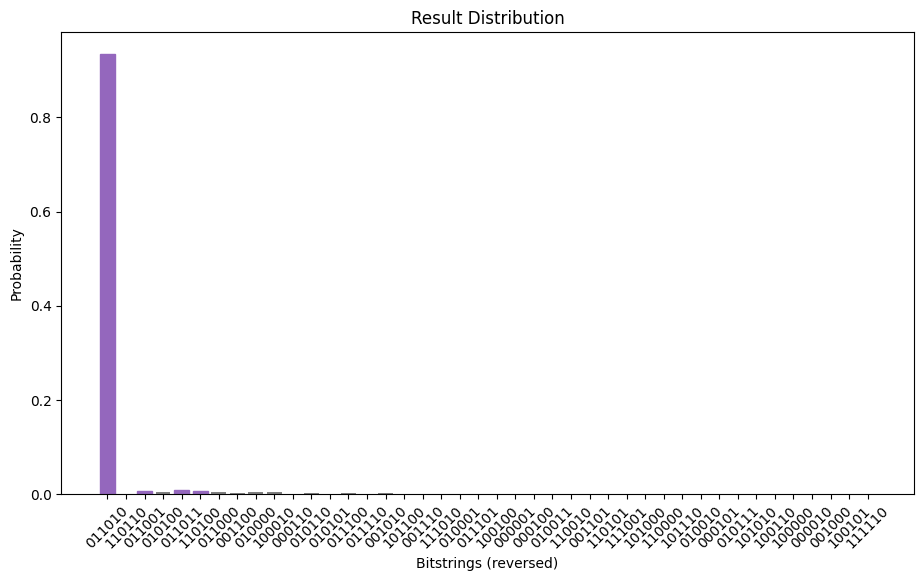

In [23]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin  # Assuming final_distribution_bin is defined elsewhere
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.extend(np.where(values == value)[0].tolist())  # Extract as a list to get individual elements

fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")

# Ensure each position is an integer index for setting color
for p in positions:
    ax.get_children()[p].set_color("tab:purple")

plt.show()